CSV file created successfully.

Training Model...
Training Complete.

----------------------------------------
Test Runner [Speed: 25 km/h, Ammo: 1]
Survival Probability: 1.0000
Prediction: SURVIVE (1)
----------------------------------------


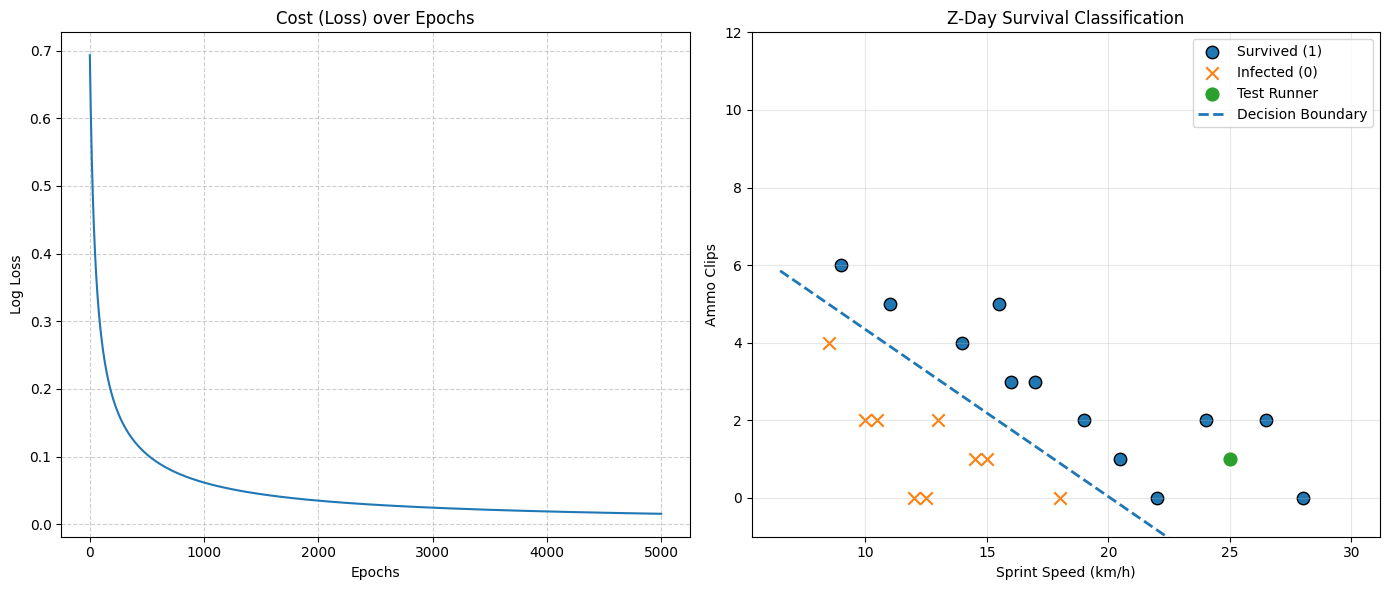

In [3]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Create the CSV file
# -----------------------------
filename = "zombies_data.csv"

data_rows = [
    ["SprintSpeed", "AmmoClips", "Result"],
    [12, 0, 0],
    [14.5, 1, 0],
    [10, 2, 0],
    [18, 0, 0],
    [8.5, 4, 0],
    [15, 1, 0],
    [22, 0, 1],
    [11, 5, 1],
    [13, 2, 0],
    [20.5, 1, 1],
    [24, 2, 1],
    [16, 3, 1],
    [12.5, 0, 0],
    [28, 0, 1],
    [9, 6, 1],
    [25, 1, 1],
    [14, 4, 1],
    [19, 2, 1],
    [10.5, 2, 0],
    [26.5, 2, 1],
    [15.5, 5, 1],
    [17, 3, 1]
]

with open(filename, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(data_rows)

print("CSV file created successfully.\n")


# -----------------------------
# 2) Read and prepare data
# -----------------------------
def read_zombie_data(path):
    features = []
    labels = []

    with open(path, "r") as f:
        next(f)  # skip header
        for row in f:
            speed, ammo, result = row.strip().split(",")
            features.append([float(speed), float(ammo)])
            labels.append(int(result))

    return np.array(features, dtype=float), np.array(labels, dtype=int)


X, y = read_zombie_data(filename)

# normalize features
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

X_scaled = (X - mu) / sigma

# add intercept column
X_train = np.c_[np.ones(X_scaled.shape[0]), X_scaled]


# -----------------------------
# 3) Logistic regression
# -----------------------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def train_logreg(X, y, learning_rate=0.1, epochs=5000):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    losses = []

    eps = 1e-15

    for _ in range(epochs):
        scores = X @ theta
        probs = sigmoid(scores)

        loss = -(1 / n_samples) * np.sum(
            y * np.log(probs + eps) + (1 - y) * np.log(1 - probs + eps)
        )
        losses.append(loss)

        gradient = (1 / n_samples) * (X.T @ (probs - y))
        theta -= learning_rate * gradient

    return theta, losses


print("Training Model...")
theta, losses = train_logreg(X_train, y, learning_rate=0.1, epochs=5000)
print("Training Complete.\n")


# -----------------------------
# 4) Test prediction
# -----------------------------
test_runner = np.array([25, 1], dtype=float)
test_runner_scaled = (test_runner - mu) / sigma
test_runner_final = np.r_[1.0, test_runner_scaled]

score = test_runner_final @ theta
prob = sigmoid(score)
pred = 1 if prob >= 0.5 else 0
result_text = "SURVIVE" if pred == 1 else "INFECTED"

print("-" * 40)
print(f"Test Runner [Speed: 25 km/h, Ammo: 1]")
print(f"Survival Probability: {prob:.4f}")
print(f"Prediction: {result_text} ({pred})")
print("-" * 40)


# -----------------------------
# 5) Visualization
# -----------------------------
plt.figure(figsize=(14, 6))

# loss curve
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Cost (Loss) over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.grid(True, linestyle="--", alpha=0.6)

# decision boundary
plt.subplot(1, 2, 2)

survivors = X[y == 1]
infected = X[y == 0]

plt.scatter(
    survivors[:, 0], survivors[:, 1],
    s=80, label="Survived (1)", edgecolors="k"
)
plt.scatter(
    infected[:, 0], infected[:, 1],
    s=80, label="Infected (0)", marker="x"
)

plt.scatter(
    test_runner[0], test_runner[1],
    s=150, label="Test Runner", zorder=5,
    edgecolors="white", linewidth=2
)

# decision boundary:
# theta0 + theta1*(x1-mu1)/sigma1 + theta2*(x2-mu2)/sigma2 = 0
# solve for x2
theta0, theta1, theta2 = theta
mu1, mu2 = mu
s1, s2 = sigma

x_vals = np.linspace(X[:, 0].min() - 2, X[:, 0].max() + 2, 200)

# avoid divide-by-zero just in case
if abs(theta2) > 1e-12:
    y_boundary = mu2 - (s2 / theta2) * (theta0 + theta1 * ((x_vals - mu1) / s1))
    plt.plot(x_vals, y_boundary, linestyle="--", linewidth=2, label="Decision Boundary")

plt.title("Z-Day Survival Classification")
plt.xlabel("Sprint Speed (km/h)")
plt.ylabel("Ammo Clips")
plt.ylim(-1, 12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()